In [117]:
import pandas as pd
import psycopg2
from dotenv import load_dotenv
import os

# Carrega credenciais do .env
load_dotenv('scraper/db/.env')
conn = psycopg2.connect(os.getenv('DATABASE_URL'))

# Carrega dados em DataFrame
query = """
    SELECT *
    FROM veiculos
    WHERE data_referencia >= CURRENT_DATE - INTERVAL '45 days'
"""
df = pd.read_sql_query(query, conn)
conn.close()

C:\Users\gpappetti_notebk\AppData\Local\Temp\ipykernel_3488\336109432.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [118]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

In [119]:
df_copy = df.copy()
df_copy = df_copy.drop(columns=['marca', 'modelo', 'odometro', 'cidade_estado', 'ano_modelo_raw', 'preco','data_referencia', 'created_at', 'id'])
jeep = df_copy[(df_copy['marca_norm'] == 'JEEP') & (df['modelo_norm'] == 'RENEGADE')]
jeep = jeep.drop_duplicates(keep='first')
longitude = jeep[jeep['versao'].isin(['LONGITUDE 1.3 16V TURBO 270 FLEX AUTOMATICO', 'Long. T270 1.3 Tb 4X2 Flex Aut.'])] 

In [120]:
# Prepara features numéricas para o modelo
# Numéricas: mantidas | Categóricas (texto): one-hot encoding
features_numericas = ['odometro_num', 'ano_fabricacao', 'ano_modelo']
categoricas = ['versao', 'cambio', 'cidade', 'estado', 'fornecedora']

X = longitude[features_numericas + categoricas].copy()
y = longitude['preco_num'].copy()

# Remove linhas sem preço (não dá para treinar sem o valor alvo)
mask = y.notna()
X, y = X[mask], y[mask]

# Preenche valores faltantes numéricos com a mediana
for col in features_numericas:
    X[col] = X[col].fillna(X[col].median())

# Transforma colunas de texto em números (one-hot encoding)
X = pd.get_dummies(X, columns=categoricas, drop_first=True)
print(f"Linhas: {len(X)} | Features: {X.shape[1]}")

Linhas: 2812 | Features: 204


In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

Treino: 2249 | Teste: 563


In [122]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(n_estimators=200, random_state=42)
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Erro médio absoluto (MAE): R$ {mae:,.2f}")
print(f"RMSE: R$ {rmse:,.2f}")
print(f"R²: {r2:.3f}  (1.0 = previsão perfeita)")

Erro médio absoluto (MAE): R$ 2,234.12
RMSE: R$ 3,708.05
R²: 0.895  (1.0 = previsão perfeita)


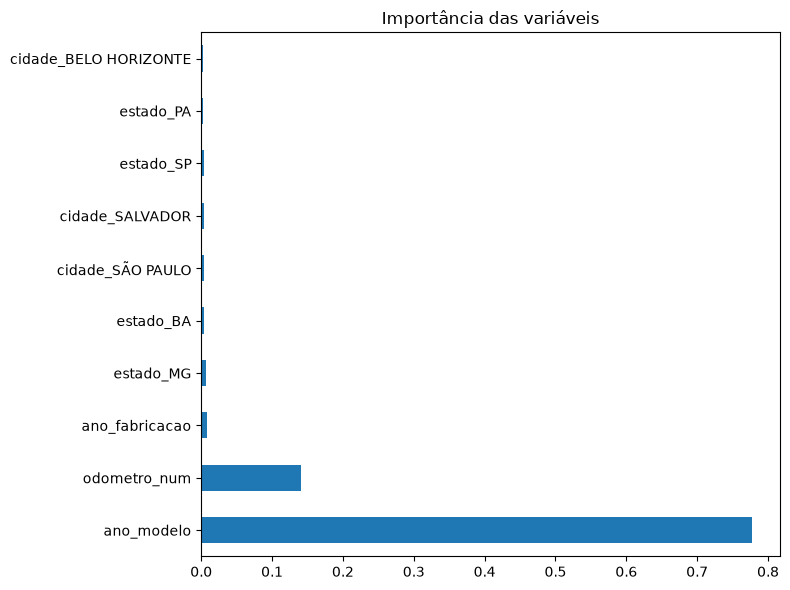

In [124]:
importancia = pd.Series(modelo.feature_importances_, index=X.columns)
importancia.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8, 6))
plt.title('Importância das variáveis')
plt.tight_layout()
plt.show()

In [125]:
# Exemplo: Renegade Longitude 2022, 30.000 km, SP, Movida
novo = pd.DataFrame([{
    'odometro_num': 30000,
    'ano_fabricacao': 2021,
    'ano_modelo': 2022
}])

# Garante as mesmas colunas do treino (categóricas zeradas)
novo = novo.reindex(columns=X.columns, fill_value=0)

preco_previsto = modelo.predict(novo)[0]
print(f"Preço previsto: R$ {preco_previsto:,.2f}")

Preço previsto: R$ 107,022.35


## Estimativa de vendas mensais (Localiza x Movida)

O banco não tem um ID único de veículo nem um status de "vendido" — cada linha é uma
fotografia diária do estoque anunciado. A estimativa abaixo usa a seguinte lógica:

1. Monta uma "chave do veículo" com atributos que não mudam (fornecedora, marca, modelo,
   versão, ano/modelo e odômetro). Cidade/estado foi deixada de fora de propósito, pois as
   fornecedoras podem transferir o mesmo carro entre lojas/cidades próximas sem que isso
   signifique uma venda.
2. Para cada chave, calcula a última data em que o carro apareceu no estoque (`ultima_data`).
3. Se essa última data for anterior à última data coletada no banco (com uma margem de
   segurança de alguns dias, para não confundir falha de coleta com saída real), considera-se
   que o carro **saiu do estoque** (vendido ou retirado) naquele mês.
4. Agrupa as saídas por fornecedora e mês, e tira a média mensal (ignorando o mês corrente,
   que está sempre incompleto).

É uma estimativa (proxy de "saída de estoque"), não um número oficial de vendas.

In [ ]:
import pandas as pd
import psycopg2
from dotenv import load_dotenv
import os

# --- 1) Carrega TODO o histórico (não só os últimos 45 dias) ---
load_dotenv('scraper/db/.env')
conn = psycopg2.connect(os.getenv('DATABASE_URL'))

query_vendas = """
    SELECT fornecedora, marca_norm, modelo_norm, versao, ano_modelo_raw,
           odometro_num, data_referencia
    FROM veiculos
"""
df_vendas = pd.read_sql_query(query_vendas, conn)
conn.close()

df_vendas['data_referencia'] = pd.to_datetime(df_vendas['data_referencia'])

# --- 2) Chave do veículo (proxy de identidade, já que não há ID/placa) ---
chave_cols = ['fornecedora', 'marca_norm', 'modelo_norm', 'versao',
              'ano_modelo_raw', 'odometro_num']
df_vendas['chave'] = df_vendas[chave_cols].astype(str).agg('|'.join, axis=1)

# --- 3) Primeira e última data em que cada chave aparece no estoque ---
agg = df_vendas.groupby(['fornecedora', 'chave'])['data_referencia'].agg(['min', 'max'])
agg = agg.rename(columns={'min': 'primeira_data', 'max': 'ultima_data'})

ultima_data_coletada = df_vendas['data_referencia'].max()
margem_seguranca = pd.Timedelta(days=4)  # tolera falhas pontuais de coleta

# Considera "saída do estoque" (venda estimada) quando o carro para de aparecer
# bem antes da última coleta disponível
agg['saiu_do_estoque'] = agg['ultima_data'] <= (ultima_data_coletada - margem_seguranca)

vendas = agg[agg['saiu_do_estoque']].copy()
vendas['mes'] = vendas['ultima_data'].dt.to_period('M')

# --- 4) Vendas estimadas por fornecedora e mês ---
vendas_por_mes = (
    vendas.reset_index()
    .groupby(['fornecedora', 'mes'])
    .size()
    .rename('veiculos_saida')
    .reset_index()
)

# Remove o mês corrente (sempre incompleto / enviesado para baixo)
mes_atual = ultima_data_coletada.to_period('M')
vendas_por_mes_completo = vendas_por_mes[vendas_por_mes['mes'] != mes_atual]

print("Vendas (saídas de estoque) estimadas por fornecedora e mês:")
display(vendas_por_mes_completo.sort_values(['fornecedora', 'mes']))

# --- 5) Média mensal por fornecedora ---
media_mensal = (
    vendas_por_mes_completo
    .groupby('fornecedora')['veiculos_saida']
    .mean()
    .round(0)
    .rename('media_veiculos_por_mes')
)

print("\nMédia estimada de carros vendidos por mês:")
display(media_mensal)